In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# Mount Google Drive (if your dataset is there)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
DATASET_PATH = "/content/drive/MyDrive/dataset_daun_jagung/"

# ⚡ FIX #1: Salin dataset dari Drive ke SSD lokal Colab (3–5x lebih cepat per epoch)
# Drive I/O sangat lambat; SSD lokal Colab jauh lebih kencang.
import shutil

LOCAL_PATH = "/content/dataset_jagung/"

if not os.path.exists(LOCAL_PATH):
    print("📂 Menyalin dataset dari Drive ke storage lokal Colab...")
    print("   (Proses ini hanya berjalan sekali, ±1–2 menit)")
    shutil.copytree(DATASET_PATH, LOCAL_PATH)
    print("✅ Selesai! Dataset siap digunakan dari lokal.")
else:
    print("✅ Dataset sudah tersedia di lokal, skip copy.")

train_dir = os.path.join(LOCAL_PATH, "train")
test_dir  = os.path.join(LOCAL_PATH, "val")
print(f"Train dir : {train_dir}")
print(f"Val dir   : {test_dir}")


📂 Menyalin dataset dari Drive ke storage lokal Colab...
   (Proses ini hanya berjalan sekali, ±1–2 menit)
✅ Selesai! Dataset siap digunakan dari lokal.
Train dir : /content/dataset_jagung/train
Val dir   : /content/dataset_jagung/val


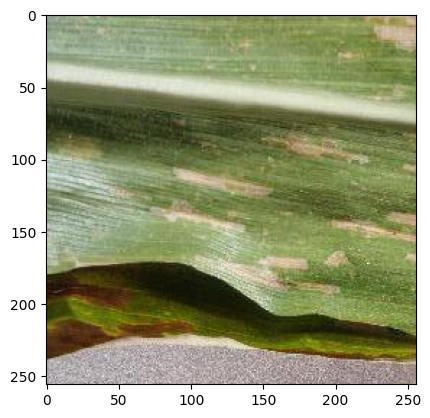

In [7]:
import matplotlib.image as mpimg

plt.imshow(mpimg.imread(os.path.join(train_dir, "Bercak_Daun/0a01cc10-3892-4311-9c48-0ac6ab3c7c43___RS_GLSp 9352_90deg.JPG")))
plt.show()

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# All images will be rescaled by 1./255
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,           # Kurangi dari 40
    width_shift_range=0.15,      # Kurangi dari 0.2
    height_shift_range=0.15,     # Kurangi dari 0.2
    shear_range=0.15,           # Kurangi dari 0.2
    zoom_range=0.15,            # Kurangi dari 0.2
    horizontal_flip=True,
    vertical_flip=True,         # Tambahkan vertical flip
    brightness_range=[0.8, 1.2], # Tambahkan brightness
    fill_mode='nearest',
    # Tambahkan channel shift
    channel_shift_range=0.1
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=True
)

Found 7316 images belonging to 4 classes.


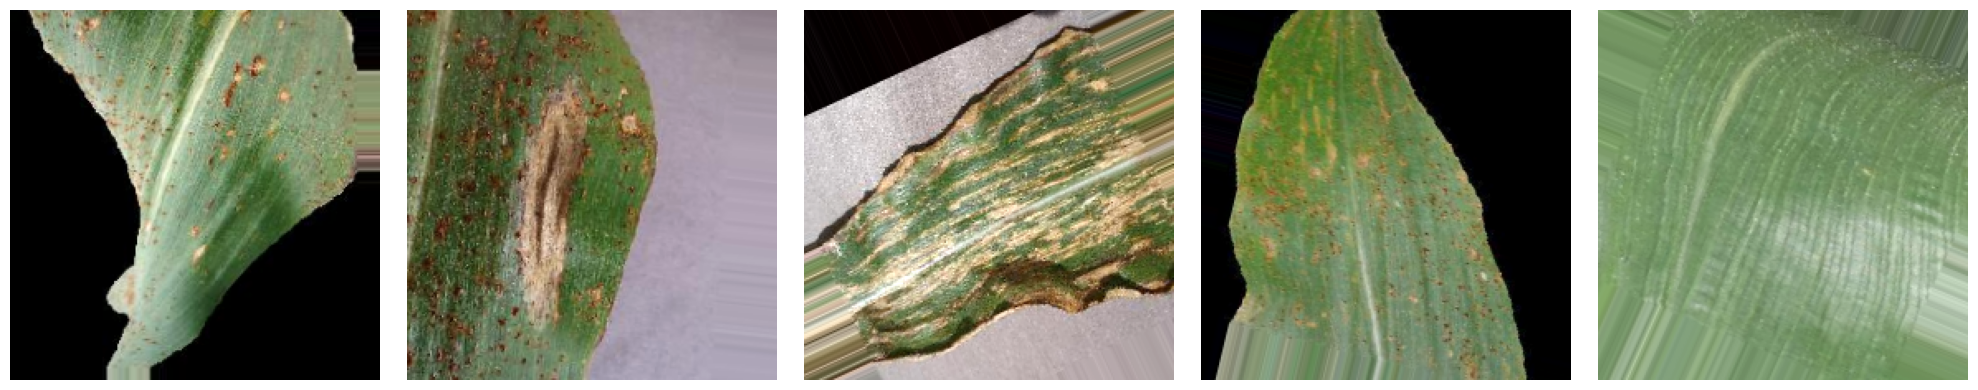

In [11]:
# Perbaikan untuk menampilkan augmented images
def plotImages(images_arr):
    fig, axes = plt.subplots(1, len(images_arr), figsize=(20, 4))
    if len(images_arr) == 1:
        axes = [axes]

    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Cara yang benar untuk mendapatkan augmented images
sample_batch = next(train_generator)
augmented_images = sample_batch[0][:5]  # Ambil 5 gambar pertama
plotImages(augmented_images)

In [21]:
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    shuffle=False   # <-- tambahkan ini
)

Found 1829 images belonging to 4 classes.


In [13]:
print("Training classes found:", train_generator.class_indices)
print("Number of training samples:", train_generator.samples)
print("Number of validation samples:", validation_generator.samples)
print("Number of classes:", train_generator.num_classes)

Training classes found: {'Bercak_Daun': 0, 'Hawar_Daun': 1, 'Karat_Daun': 2, 'Sehat': 3}
Number of training samples: 7316
Number of validation samples: 1829
Number of classes: 4


In [14]:
# Model dengan lebih banyak layer dan batch normalization
model = tf.keras.models.Sequential([
    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Block 4
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # Classifier
    tf.keras.layers.GlobalAveragePooling2D(),  # Lebih baik dari Flatten
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 110, 110, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 53, 53, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 51, 51, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 51, 51, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 49, 49, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 22, 22, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             

 Total params: 850,084 (3.24 MB)

 Trainable params: 848,100 (3.24 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [15]:
# Gunakan pre-trained model ()
base_model = tf.keras.applications.DenseNet121(
    input_shape=(224, 224, 3),  # Ukuran input lebih besar
    include_top=False,
    weights='imagenet'
)

# Freeze base model layers
base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
# Tambahkan custom classifier
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(4, activation='softmax')
])

In [17]:
# Gunakan learning rate scheduling
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Learning rate yang adaptif
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

# Early stopping untuk mencegah overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Simpan model terbaik
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Compile dengan optimizer yang lebih baik
model.compile(
    optimizer=Adam(learning_rate=0.001),  # Learning rate lebih tinggi di awal
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==================== STRATEGI 5: TRAINING DENGAN CALLBACKS ====================

# Training dengan lebih banyak epochs dan callbacks
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=50,  # Lebih banyak epochs
    steps_per_epoch=len(train_generator),  # Gunakan semua data
    validation_steps=len(validation_generator),
    callbacks=[reduce_lr, early_stop, checkpoint],
    verbose=1
)


Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8012 - loss: 0.5462
Epoch 1: val_accuracy improved from None to 0.95517, saving model to /content/drive/MyDrive/model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.8902 - loss: 0.3016 - val_accuracy: 0.9552 - val_loss: 0.1680 - learning_rate: 0.0010
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9341 - loss: 0.1782
Epoch 2: val_accuracy improved from 0.95517 to 0.95899, saving model to /content/drive/MyDrive/model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 185s 1s/step - accuracy: 0.9392 - loss: 0.1634 - val_accuracy: 0.9590 - val_loss: 0.1139 - learning_rate: 0.0010
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9500 - loss: 0.1446
Epoch 3: val_accuracy improved from 0.95899 to 0.96227, saving model to /content/drive/MyDrive/model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9493 - loss: 0.1386 - val_accuracy: 0.9623 - val_loss: 0.0976 - learning_rate: 0.0010
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9458 - loss: 0.1334
Epoch 4: val_accuracy improved from 0.96227 to 0.96501, saving model to /content/drive/MyDrive/model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9494 - loss: 0.1287 - val_accuracy: 0.9650 - val_loss: 0.0896 - learning_rate: 0.0010
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9570 - loss: 0.1219
Epoch 5: val_accuracy improved from 0.96501 to 0.96720, saving model to /content/drive/MyDrive/model.h5


...


Epoch 13: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9641 - loss: 0.0975 - val_accuracy: 0.9743 - val_loss: 0.0713 - learning_rate: 0.0010
Epoch 14/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9648 - loss: 0.0983
Epoch 14: val_accuracy did not improve from 0.97430
115/115 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9649 - loss: 0.0992 - val_accuracy: 0.9732 - val_loss: 0.0687 - learning_rate: 0.0010
Epoch 15/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9641 - loss: 0.0985
Epoch 15: val_accuracy improved from 0.97430 to 0.97485, saving model to /content/drive/MyDrive/model.h5



Epoch 15: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9639 - loss: 0.0958 - val_accuracy: 0.9748 - val_loss: 0.0656 - learning_rate: 0.0010
Epoch 16/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9608 - loss: 0.1020
Epoch 16: val_accuracy did not improve from 0.97485
115/115 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9621 - loss: 0.0966 - val_accuracy: 0.9748 - val_loss: 0.0679 - learning_rate: 0.0010
Epoch 17/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9631 - loss: 0.1001
Epoch 17: val_accuracy did not improve from 0.97485
115/115 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9642 - loss: 0.0921 - val_accuracy: 0.9748 - val_loss: 0.0662 - learning_rate: 0.0010
Epoch 18/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9664 - loss: 0.0857
Epoch 18: val_accuracy did not improve from 0.97485
115/115 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9657 - loss: 0.0863 - val_accuracy: 


Epoch 21: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9651 - loss: 0.0904 - val_accuracy: 0.9754 - val_loss: 0.0598 - learning_rate: 0.0010
Epoch 22/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9708 - loss: 0.0791
Epoch 22: val_accuracy did not improve from 0.97540
115/115 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9691 - loss: 0.0828 - val_accuracy: 0.9727 - val_loss: 0.0616 - learning_rate: 0.0010
Epoch 23/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9680 - loss: 0.0859
Epoch 23: val_accuracy did not improve from 0.97540
115/115 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9664 - loss: 0.0881 - val_accuracy: 0.9710 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 24/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9685 - loss: 0.0894
Epoch 24: val_accuracy did not improve from 0.97540
115/115 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9675 - loss: 0.0886 - val_accuracy: 


Epoch 25: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9687 - loss: 0.0785 - val_accuracy: 0.9770 - val_loss: 0.0612 - learning_rate: 0.0010
Epoch 26/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9671 - loss: 0.0824
Epoch 26: val_accuracy did not improve from 0.97704
115/115 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9698 - loss: 0.0791 - val_accuracy: 0.9754 - val_loss: 0.0582 - learning_rate: 0.0010
Epoch 27/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9668 - loss: 0.0801
Epoch 27: val_accuracy improved from 0.97704 to 0.97813, saving model to /content/drive/MyDrive/model.h5



Epoch 27: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9657 - loss: 0.0846 - val_accuracy: 0.9781 - val_loss: 0.0565 - learning_rate: 0.0010
Epoch 28/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9693 - loss: 0.0780
Epoch 28: val_accuracy did not improve from 0.97813
115/115 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9686 - loss: 0.0855 - val_accuracy: 0.9765 - val_loss: 0.0575 - learning_rate: 0.0010
Epoch 29/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9744 - loss: 0.0780
Epoch 29: val_accuracy did not improve from 0.97813
115/115 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9728 - loss: 0.0778 - val_accuracy: 0.9776 - val_loss: 0.0581 - learning_rate: 0.0010
Epoch 30/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9693 - loss: 0.0816
Epoch 30: val_accuracy did not improve from 0.97813
115/115 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9694 - loss: 0.0850 - val_accuracy: 

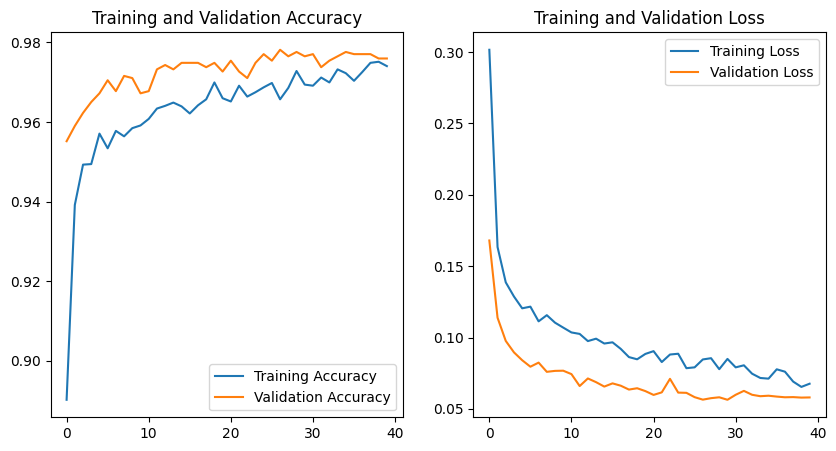

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = np.arange(len(history.history['accuracy']))

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [22]:
print("="*50)
print("MODEL EVALUATION")
print("="*50)

# 1. Evaluasi pada test set
print("Evaluating model on test set...")
test_loss, test_accuracy = model.evaluate(validation_generator, verbose=1)
print(f"\nTest Results:")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

print("="*50)
print("EVALUATION COMPLETE")
print("="*50)

MODEL EVALUATION
Evaluating model on test set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.9765 - loss: 0.0564

Test Results:
Test Accuracy: 0.9765 (97.65%)
Test Loss: 0.0564
EVALUATION COMPLETE


Menghasilkan prediksi pada validation set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step

Kelas: ['Bercak_Daun', 'Hawar_Daun', 'Karat_Daun', 'Sehat']

  RINGKASAN METRIK EVALUASI
  Akurasi   : 0.9765  (97.65%)
  Presisi   : 0.9765  (97.65%)
  Recall    : 0.9765  (97.65%)
  F1-Score  : 0.9765  (97.65%)

Classification Report (per kelas):
-------------------------------------------------------
              precision    recall  f1-score   support

 Bercak_Daun       0.95      0.95      0.95       410
  Hawar_Daun       0.95      0.96      0.96       477
  Karat_Daun       1.00      1.00      1.00       477
       Sehat       1.00      0.99      1.00       465

    accuracy                           0.98      1829
   macro avg       0.98      0.98      0.98      1829
weighted avg       0.98      0.98      0.98      1829



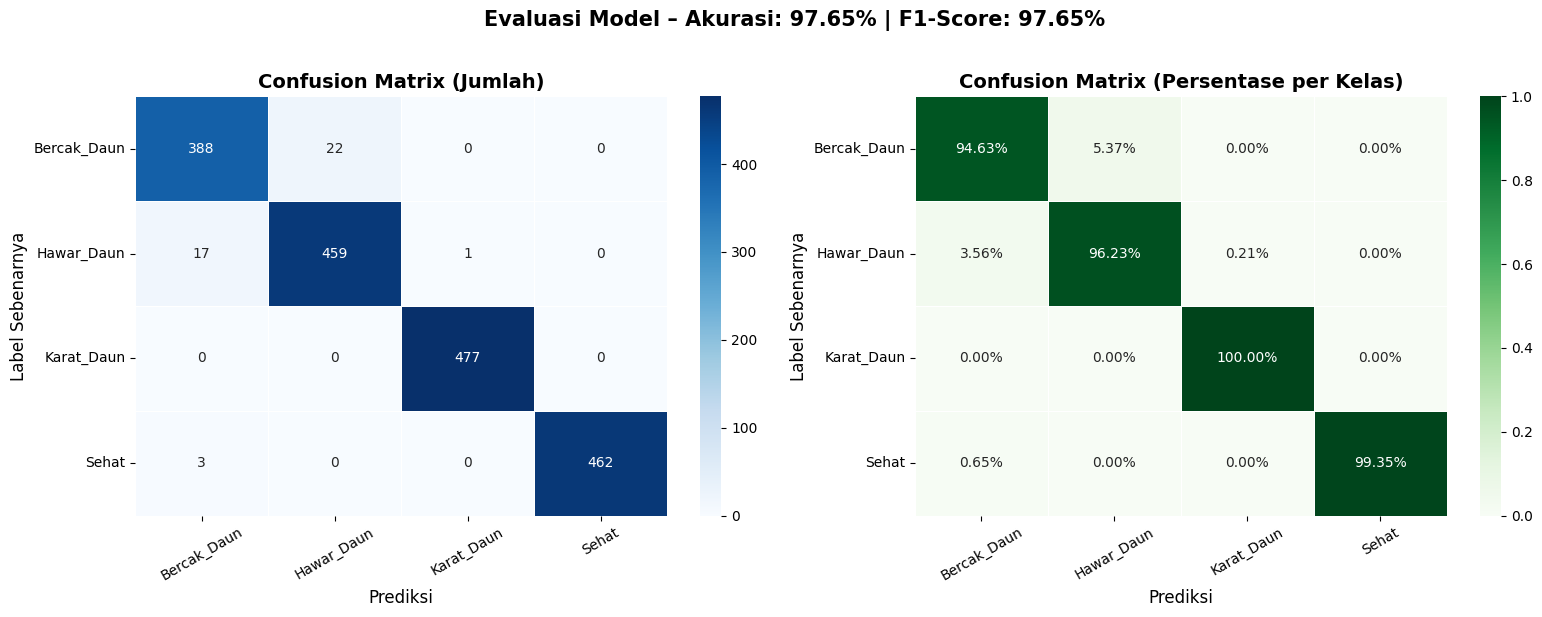

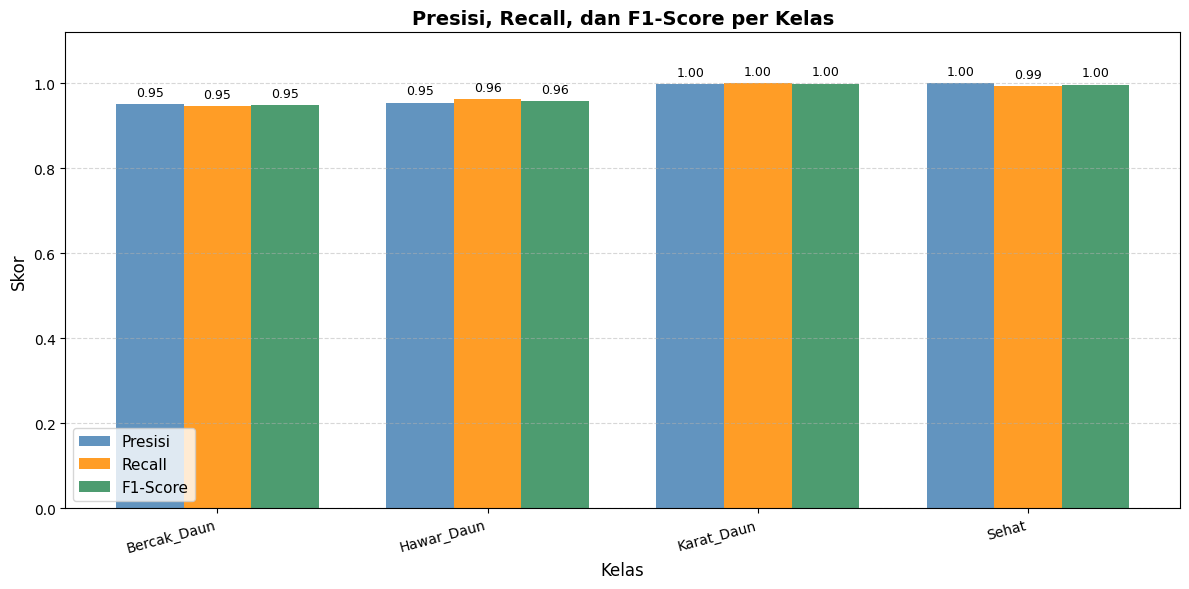

In [23]:
# ============================================================
# CONFUSION MATRIX & CLASSIFICATION REPORT
# Akurasi, Presisi, Recall, dan F1-Score
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --- 1. Ambil prediksi dari validation generator ---
print("Menghasilkan prediksi pada validation set...")

# Reset generator agar mulai dari awal
validation_generator.reset()

# Prediksi semua batch
y_pred_probs = model.predict(
    validation_generator,
    steps=len(validation_generator),
    verbose=1
)

# Konversi probabilitas → index kelas prediksi
y_pred = np.argmax(y_pred_probs, axis=1)

# Label kelas sebenarnya
y_true = validation_generator.classes

# Nama kelas
class_names = list(validation_generator.class_indices.keys())
print("\nKelas:", class_names)

# --- 2. Hitung metrik ---
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\n" + "="*55)
print("  RINGKASAN METRIK EVALUASI")
print("="*55)
print(f"  Akurasi   : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Presisi   : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("="*55)

# --- 3. Classification report per kelas ---
print("\nClassification Report (per kelas):")
print("-"*55)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# --- 4. Confusion Matrix – heatmap ---
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # normalisasi per baris

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 4a. Confusion matrix (jumlah absolut) ---
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Jumlah)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prediksi', fontsize=12)
axes[0].set_ylabel('Label Sebenarnya', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# --- 4b. Confusion matrix (persentase per baris) ---
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Persentase per Kelas)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prediksi', fontsize=12)
axes[1].set_ylabel('Label Sebenarnya', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(
    f'Evaluasi Model – Akurasi: {acc*100:.2f}% | F1-Score: {f1*100:.2f}%',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# --- 5. Bar chart metrik per kelas ---
report_dict = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_precision = [report_dict[c]['precision'] for c in class_names]
per_class_recall    = [report_dict[c]['recall']    for c in class_names]
per_class_f1        = [report_dict[c]['f1-score']  for c in class_names]

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, per_class_precision, width, label='Presisi',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x,         per_class_recall,    width, label='Recall',   color='darkorange', alpha=0.85)
bars3 = ax.bar(x + width, per_class_f1,        width, label='F1-Score', color='seagreen',   alpha=0.85)

# Tambahkan nilai di atas bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Kelas', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Presisi, Recall, dan F1-Score per Kelas', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15, ha='right')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [24]:
# Setelah training pertama, unfreeze beberapa layer terakhir
base_model.trainable = True

# Fine-tune hanya layer terakhir
fine_tune_at = 100  # Freeze layer sebelum ini

# Freeze layer awal
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Compile ulang dengan learning rate yang sangat kecil
model.compile(
    optimizer=Adam(learning_rate=0.0001/10),  # Learning rate 10x lebih kecil
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tuning training
fine_tune_epochs = 20
total_epochs = len(history.history['accuracy']) + fine_tune_epochs

history_fine = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=total_epochs,
    initial_epoch=len(history.history['accuracy']),
    steps_per_epoch=len(train_generator),
    validation_steps=len(validation_generator),
    callbacks=[reduce_lr, early_stop, checkpoint],
    verbose=1
)

Epoch 41/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9547 - loss: 0.1236
Epoch 41: val_accuracy did not improve from 0.97813
115/115 ━━━━━━━━━━━━━━━━━━━━ 480s 3s/step - accuracy: 0.9569 - loss: 0.1156 - val_accuracy: 0.9716 - val_loss: 0.0723 - learning_rate: 1.0000e-05
Epoch 42/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9651 - loss: 0.0906
Epoch 42: val_accuracy did not improve from 0.97813
115/115 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9676 - loss: 0.0869 - val_accuracy: 0.9743 - val_loss: 0.0727 - learning_rate: 1.0000e-05
Epoch 43/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9709 - loss: 0.0816
Epoch 43: val_accuracy did not improve from 0.97813
115/115 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9697 - loss: 0.0818 - val_accuracy: 0.9748 - val_loss: 0.0655 - learning_rate: 1.0000e-05
Epoch 44/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9754 - loss: 0.0653
Epoch 44: val_accuracy did not improve from 0.97813
115/115 ━━


Epoch 47: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.9800 - loss: 0.0523 - val_accuracy: 0.9787 - val_loss: 0.0552 - learning_rate: 2.0000e-06
Epoch 48/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9775 - loss: 0.0545
Epoch 48: val_accuracy did not improve from 0.97868
115/115 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9764 - loss: 0.0577 - val_accuracy: 0.9781 - val_loss: 0.0539 - learning_rate: 2.0000e-06
Epoch 49/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9790 - loss: 0.0534
Epoch 49: val_accuracy improved from 0.97868 to 0.97922, saving model to /content/drive/MyDrive/model.h5



Epoch 49: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9772 - loss: 0.0567 - val_accuracy: 0.9792 - val_loss: 0.0543 - learning_rate: 2.0000e-06
Epoch 50/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9806 - loss: 0.0535
Epoch 50: val_accuracy did not improve from 0.97922
115/115 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9798 - loss: 0.0539 - val_accuracy: 0.9781 - val_loss: 0.0532 - learning_rate: 2.0000e-06
Epoch 51/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9802 - loss: 0.0538
Epoch 51: val_accuracy did not improve from 0.97922
115/115 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.9792 - loss: 0.0544 - val_accuracy: 0.9781 - val_loss: 0.0520 - learning_rate: 2.0000e-06
Epoch 52/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9763 - loss: 0.0650
Epoch 52: val_accuracy did not improve from 0.97922
115/115 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.9791 - loss: 0.0538 - va


Epoch 53: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.9794 - loss: 0.0539 - val_accuracy: 0.9803 - val_loss: 0.0514 - learning_rate: 2.0000e-06
Epoch 54/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9799 - loss: 0.0521
Epoch 54: val_accuracy improved from 0.98032 to 0.98086, saving model to /content/drive/MyDrive/model.h5



Epoch 54: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9809 - loss: 0.0495 - val_accuracy: 0.9809 - val_loss: 0.0502 - learning_rate: 2.0000e-06
Epoch 55/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9805 - loss: 0.0522
Epoch 55: val_accuracy did not improve from 0.98086
115/115 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9818 - loss: 0.0491 - val_accuracy: 0.9809 - val_loss: 0.0496 - learning_rate: 2.0000e-06
Epoch 56/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9841 - loss: 0.0432
Epoch 56: val_accuracy did not improve from 0.98086
115/115 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9824 - loss: 0.0478 - val_accuracy: 0.9803 - val_loss: 0.0499 - learning_rate: 2.0000e-06
Epoch 57/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9796 - loss: 0.0506
Epoch 57: val_accuracy did not improve from 0.98086
115/115 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.9805 - loss: 0.0517 - va


Epoch 58: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.9794 - loss: 0.0523 - val_accuracy: 0.9814 - val_loss: 0.0500 - learning_rate: 2.0000e-06
Epoch 59/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9823 - loss: 0.0487
Epoch 59: val_accuracy improved from 0.98141 to 0.98196, saving model to /content/drive/MyDrive/model.h5



Epoch 59: finished saving model to /content/drive/MyDrive/model.h5
115/115 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9832 - loss: 0.0461 - val_accuracy: 0.9820 - val_loss: 0.0479 - learning_rate: 2.0000e-06
Epoch 60/60
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9804 - loss: 0.0519
Epoch 60: val_accuracy did not improve from 0.98196
115/115 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.9817 - loss: 0.0475 - val_accuracy: 0.9820 - val_loss: 0.0477 - learning_rate: 2.0000e-06
Restoring model weights from the end of the best epoch: 60.


Menghasilkan prediksi pada validation set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 690ms/step

Kelas: ['Bercak_Daun', 'Hawar_Daun', 'Karat_Daun', 'Sehat']

  RINGKASAN METRIK EVALUASI
  Akurasi   : 0.9820  (98.20%)
  Presisi   : 0.9822  (98.22%)
  Recall    : 0.9820  (98.20%)
  F1-Score  : 0.9819  (98.19%)

Classification Report (per kelas):
-------------------------------------------------------
              precision    recall  f1-score   support

 Bercak_Daun       0.98      0.94      0.96       410
  Hawar_Daun       0.95      0.98      0.97       477
  Karat_Daun       1.00      1.00      1.00       477
       Sehat       1.00      1.00      1.00       465

    accuracy                           0.98      1829
   macro avg       0.98      0.98      0.98      1829
weighted avg       0.98      0.98      0.98      1829



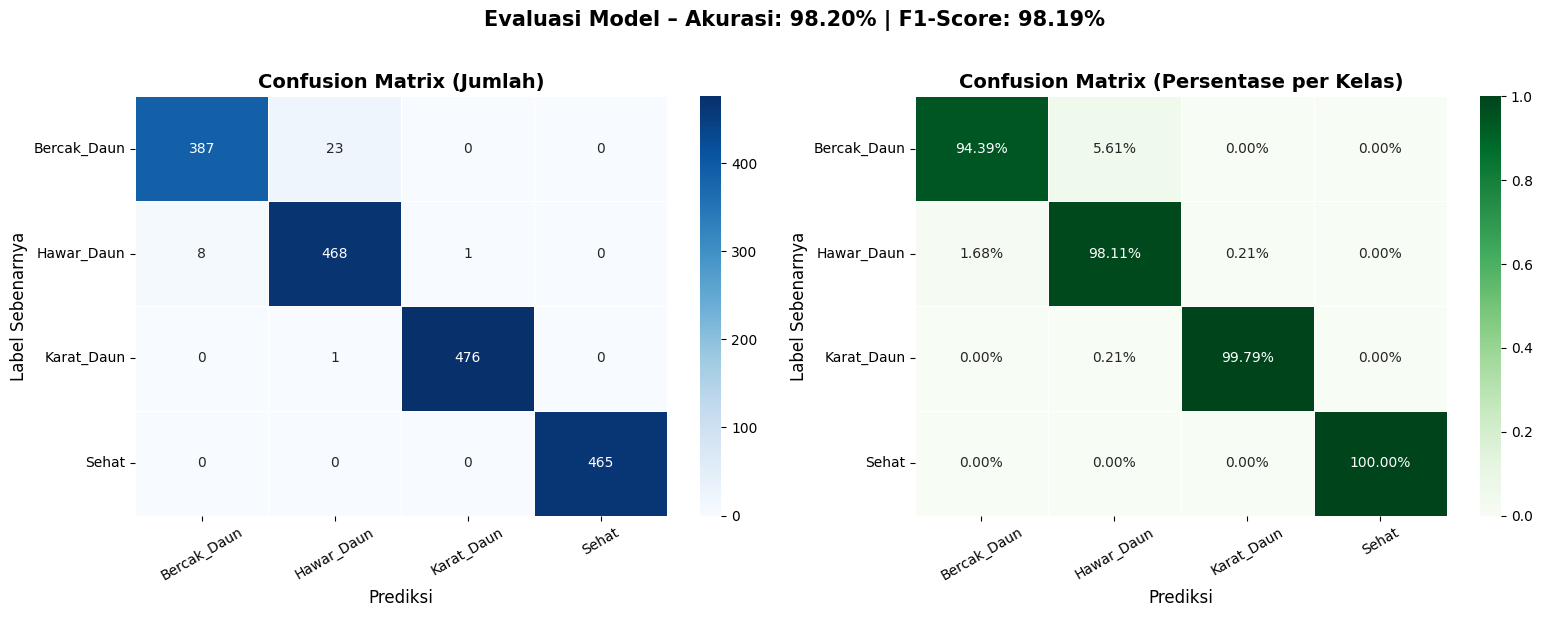

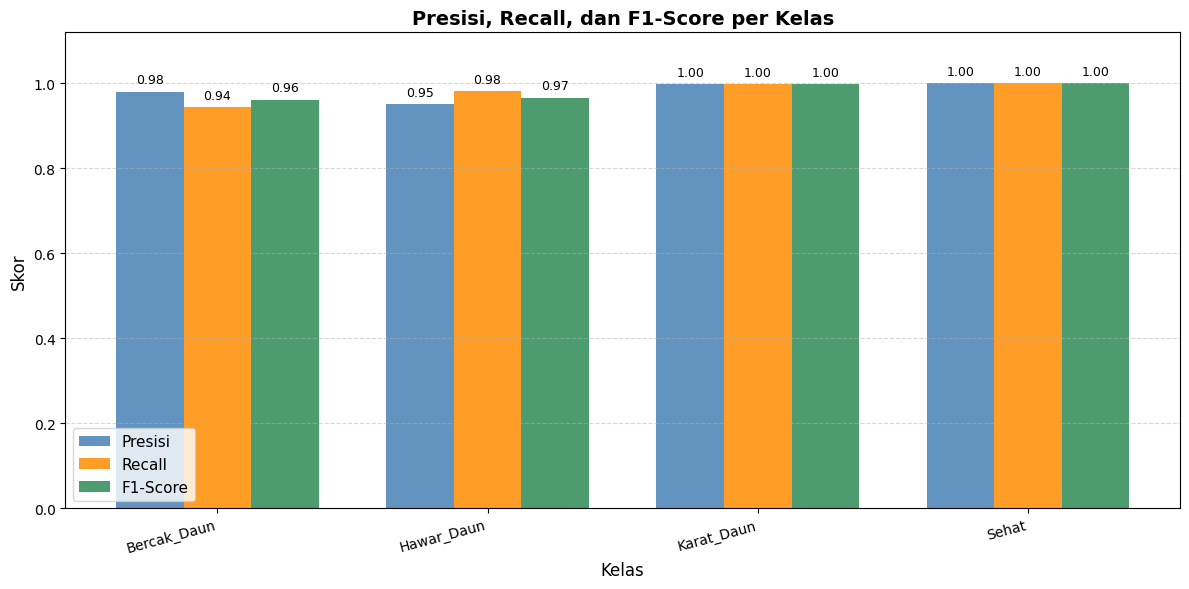

In [26]:
# ============================================================
# CONFUSION MATRIX & CLASSIFICATION REPORT
# Akurasi, Presisi, Recall, dan F1-Score
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --- 1. Ambil prediksi dari validation generator ---
print("Menghasilkan prediksi pada validation set...")

# Reset generator agar mulai dari awal
validation_generator.reset()

# Prediksi semua batch
y_pred_probs = model.predict(
    validation_generator,
    steps=len(validation_generator),
    verbose=1
)

# Konversi probabilitas → index kelas prediksi
y_pred = np.argmax(y_pred_probs, axis=1)

# Label kelas sebenarnya
y_true = validation_generator.classes

# Nama kelas
class_names = list(validation_generator.class_indices.keys())
print("\nKelas:", class_names)

# --- 2. Hitung metrik ---
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall    = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\n" + "="*55)
print("  RINGKASAN METRIK EVALUASI")
print("="*55)
print(f"  Akurasi   : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Presisi   : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("="*55)

# --- 3. Classification report per kelas ---
print("\nClassification Report (per kelas):")
print("-"*55)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

# --- 4. Confusion Matrix – heatmap ---
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)  # normalisasi per baris

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 4a. Confusion matrix (jumlah absolut) ---
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title('Confusion Matrix (Jumlah)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prediksi', fontsize=12)
axes[0].set_ylabel('Label Sebenarnya', fontsize=12)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# --- 4b. Confusion matrix (persentase per baris) ---
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=0.5, ax=axes[1]
)
axes[1].set_title('Confusion Matrix (Persentase per Kelas)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prediksi', fontsize=12)
axes[1].set_ylabel('Label Sebenarnya', fontsize=12)
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle(
    f'Evaluasi Model – Akurasi: {acc*100:.2f}% | F1-Score: {f1*100:.2f}%',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# --- 5. Bar chart metrik per kelas ---
report_dict = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

per_class_precision = [report_dict[c]['precision'] for c in class_names]
per_class_recall    = [report_dict[c]['recall']    for c in class_names]
per_class_f1        = [report_dict[c]['f1-score']  for c in class_names]

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, per_class_precision, width, label='Presisi',  color='steelblue',  alpha=0.85)
bars2 = ax.bar(x,         per_class_recall,    width, label='Recall',   color='darkorange', alpha=0.85)
bars3 = ax.bar(x + width, per_class_f1,        width, label='F1-Score', color='seagreen',   alpha=0.85)

# Tambahkan nilai di atas bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 4), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Kelas', fontsize=12)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Presisi, Recall, dan F1-Score per Kelas', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=15, ha='right')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [25]:
# Simpan model
model.save('/content/drive/MyDrive/model_final_v2.h5')
print("Model saved successfully!")

Model saved successfully!


In [ ]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from PIL import Image
import io

# Upload file
uploaded = files.upload()

# Dapatkan class names dari generator
class_names = list(train_generator.class_indices.keys())
print("Class names:", class_names)

for fn in uploaded.keys():
    path = '/content/' + fn

    # Preview gambar yang diupload
    img_display = Image.open(path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_display)
    plt.title(f'Uploaded Image: {fn}')
    plt.axis('off')
    plt.show()

    # Load dan preprocess gambar untuk prediksi
    # PERBAIKAN: Ubah target_size menjadi (224, 224) sesuai dengan yang diharapkan model
    img = image.load_img(path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = x / 255.0  # Normalisasi
    x = np.expand_dims(x, axis=0)

    # Prediksi
    predictions = model.predict(x)
    predicted_class_index = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_index]

    # Tampilkan hasil
    print(f"File: {fn}")
    print(f"Predicted class: {class_names[predicted_class_index]}")
    print(f"Confidence: {confidence:.4f}")
    print(f"All probabilities: {predictions[0]}")

    # Tampilkan probabilitas untuk setiap kelas dalam format yang lebih rapi
    print("\nProbability for each class:")
    for i, class_name in enumerate(class_names):
        print(f"  {class_name}: {predictions[0][i]:.4f}")

    print("-" * 60)